<a href="https://colab.research.google.com/github/sudip328/Random-Forest-Cs2GeX6-/blob/main/SVR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset:


,Compound,Lattice_parameter,Volume,Tolerance_factor,Octahedral_factor,Formation_energy,Band_gap
0,Cs2GeF6,9.23,786.86,1.14,0.398,-4.78,5.910
1,Cs2GeCl6,10.59,1187.00,1.05,0.293,-3.38,2.260
2,Cs2GeBr6,11.09,1365.11,1.03,0.271,-2.72,1.016
3,Cs2GeI6,11.70,1601.50,1.00,0.241,-1.03,0.000



Feature matrix shape: (4, 5)
Target shape: (4,)

Features scaled successfully.
SVR model fitted successfully!

       SVR TRAINING PERFORMANCE
RMSE = 0.0102 eV
MAE  = 0.0102 eV
R²   = 1.0000

       SVR PREDICTION RESULTS


,Compound,Actual_Band_Gap,Predicted_Band_Gap,Absolute_Error
0,Cs2GeF6,5.910,5.899774,0.010226
1,Cs2GeCl6,2.260,2.249882,0.010118
2,Cs2GeBr6,1.016,1.025774,0.009774
3,Cs2GeI6,0.000,0.010570,0.010570



       SVR LOOCV PERFORMANCE
RMSE = 2.7940 eV
MAE  = 1.9280 eV
R²   = -0.5635

       SVR LOOCV PREDICTIONS


,Compound,Actual_Band_Gap,LOOCV_Predicted_Band_Gap,Absolute_Error
0,Cs2GeF6,5.910,1.024281,4.885719
1,Cs2GeCl6,2.260,2.332875,0.072875
2,Cs2GeBr6,1.016,1.058458,0.042458
3,Cs2GeI6,0.000,2.710831,2.710831



       TRAINING VS LOOCV


,Metric,Training,LOOCV
0,RMSE (eV),0.010176,2.794010
1,MAE (eV),0.010172,1.927971
2,R²,0.999979,-0.563463


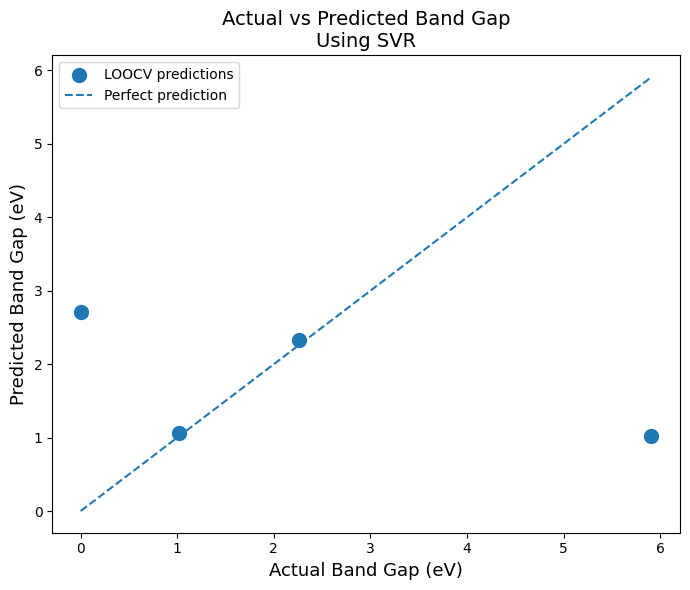

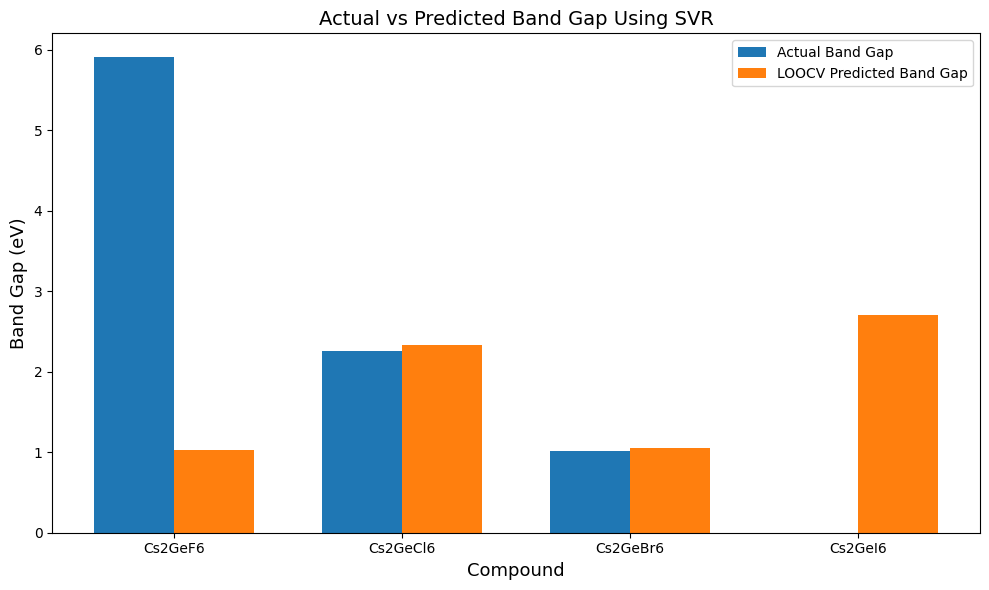

In [2]:
# ============================================================
# SUPPORT VECTOR REGRESSION (SVR)
# BAND GAP PREDICTION
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

# ============================================================
# 1. DATA
# ============================================================

data = {
    "Compound": [
        "Cs2GeF6",
        "Cs2GeCl6",
        "Cs2GeBr6",
        "Cs2GeI6"
    ],

    "Lattice_parameter": [
        9.23,
        10.59,
        11.09,
        11.70
    ],

    "Volume": [
        786.86,
        1187.00,
        1365.11,
        1601.50
    ],

    "Tolerance_factor": [
        1.14,
        1.05,
        1.03,
        1.00
    ],

    "Octahedral_factor": [
        0.398,
        0.293,
        0.271,
        0.241
    ],

    "Formation_energy": [
        -4.78,
        -3.38,
        -2.72,
        -1.03
    ],

    "Band_gap": [
        5.91,
        2.26,
        1.016,
        0.00
    ]
}

df = pd.DataFrame(data)

print("Dataset:")
display(df)

# ============================================================
# 2. FEATURES AND TARGET
# ============================================================

features = [
    "Lattice_parameter",
    "Volume",
    "Tolerance_factor",
    "Octahedral_factor",
    "Formation_energy"
]

X = df[features]
y = df["Band_gap"]

print("\nFeature matrix shape:", X.shape)
print("Target shape:", y.shape)

# ============================================================
# 3. FEATURE SCALING
# ============================================================

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("\nFeatures scaled successfully.")

# ============================================================
# 4. SVR MODEL
# ============================================================

svr_model = SVR(
    kernel="rbf",
    C=100,
    epsilon=0.01,
    gamma="scale"
)

# ============================================================
# 5. TRAIN MODEL
# ============================================================

svr_model.fit(
    X_scaled,
    y
)

print("SVR model fitted successfully!")

# ============================================================
# 6. TRAINING PREDICTIONS
# ============================================================

y_pred = svr_model.predict(
    X_scaled
)

# ============================================================
# 7. TRAINING PERFORMANCE
# ============================================================

train_rmse = np.sqrt(
    mean_squared_error(
        y,
        y_pred
    )
)

train_mae = mean_absolute_error(
    y,
    y_pred
)

train_r2 = r2_score(
    y,
    y_pred
)

print("\n" + "=" * 55)
print("       SVR TRAINING PERFORMANCE")
print("=" * 55)

print(f"RMSE = {train_rmse:.4f} eV")
print(f"MAE  = {train_mae:.4f} eV")
print(f"R²   = {train_r2:.4f}")

# ============================================================
# 8. TRAINING PREDICTION RESULTS
# ============================================================

results = pd.DataFrame({
    "Compound": df["Compound"],
    "Actual_Band_Gap": y,
    "Predicted_Band_Gap": y_pred
})

results["Absolute_Error"] = abs(
    results["Actual_Band_Gap"]
    -
    results["Predicted_Band_Gap"]
)

print("\n" + "=" * 55)
print("       SVR PREDICTION RESULTS")
print("=" * 55)

display(results)

# ============================================================
# 9. LEAVE-ONE-OUT CROSS VALIDATION
# ============================================================

loo = LeaveOneOut()

loo_predictions = []
loo_actual = []
loo_compounds = []

for train_index, test_index in loo.split(X):

    # --------------------------------------------------------
    # Split data
    # --------------------------------------------------------

    X_train = X.iloc[train_index]
    X_test = X.iloc[test_index]

    y_train = y.iloc[train_index]
    y_test = y.iloc[test_index]

    # --------------------------------------------------------
    # Scale ONLY the training data
    # --------------------------------------------------------

    scaler_loo = StandardScaler()

    X_train_scaled = scaler_loo.fit_transform(
        X_train
    )

    X_test_scaled = scaler_loo.transform(
        X_test
    )

    # --------------------------------------------------------
    # Create SVR model
    # --------------------------------------------------------

    svr_loo = SVR(
        kernel="rbf",
        C=100,
        epsilon=0.01,
        gamma="scale"
    )

    # --------------------------------------------------------
    # Fit model
    # --------------------------------------------------------

    svr_loo.fit(
        X_train_scaled,
        y_train
    )

    # --------------------------------------------------------
    # Predict left-out sample
    # --------------------------------------------------------

    prediction = svr_loo.predict(
        X_test_scaled
    )

    loo_predictions.append(
        prediction[0]
    )

    loo_actual.append(
        y_test.iloc[0]
    )

    loo_compounds.append(
        df["Compound"].iloc[test_index[0]]
    )

# ============================================================
# 10. LOOCV PERFORMANCE
# ============================================================

loo_rmse = np.sqrt(
    mean_squared_error(
        loo_actual,
        loo_predictions
    )
)

loo_mae = mean_absolute_error(
    loo_actual,
    loo_predictions
)

loo_r2 = r2_score(
    loo_actual,
    loo_predictions
)

print("\n" + "=" * 55)
print("       SVR LOOCV PERFORMANCE")
print("=" * 55)

print(f"RMSE = {loo_rmse:.4f} eV")
print(f"MAE  = {loo_mae:.4f} eV")
print(f"R²   = {loo_r2:.4f}")

# ============================================================
# 11. LOOCV RESULTS
# ============================================================

loo_results = pd.DataFrame({
    "Compound": loo_compounds,
    "Actual_Band_Gap": loo_actual,
    "LOOCV_Predicted_Band_Gap": loo_predictions
})

loo_results["Absolute_Error"] = abs(
    loo_results["Actual_Band_Gap"]
    -
    loo_results["LOOCV_Predicted_Band_Gap"]
)

print("\n" + "=" * 55)
print("       SVR LOOCV PREDICTIONS")
print("=" * 55)

display(loo_results)

# ============================================================
# 12. TRAINING VS LOOCV
# ============================================================

comparison = pd.DataFrame({
    "Metric": [
        "RMSE (eV)",
        "MAE (eV)",
        "R²"
    ],

    "Training": [
        train_rmse,
        train_mae,
        train_r2
    ],

    "LOOCV": [
        loo_rmse,
        loo_mae,
        loo_r2
    ]
})

print("\n" + "=" * 55)
print("       TRAINING VS LOOCV")
print("=" * 55)

display(comparison)

# ============================================================
# 13. ACTUAL VS PREDICTED PLOT
# ============================================================

plt.figure(figsize=(7, 6))

plt.scatter(
    loo_actual,
    loo_predictions,
    s=100,
    label="LOOCV predictions"
)

# Perfect prediction line

min_value = min(
    min(loo_actual),
    min(loo_predictions)
)

max_value = max(
    max(loo_actual),
    max(loo_predictions)
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--",
    label="Perfect prediction"
)

plt.xlabel(
    "Actual Band Gap (eV)",
    fontsize=13
)

plt.ylabel(
    "Predicted Band Gap (eV)",
    fontsize=13
)

plt.title(
    "Actual vs Predicted Band Gap\nUsing SVR",
    fontsize=14
)

plt.legend()

plt.tight_layout()
plt.show()

# ============================================================
# 14. ACTUAL VS PREDICTED FOR EACH COMPOUND
# ============================================================

x = np.arange(
    len(loo_compounds)
)

width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(
    x - width/2,
    loo_actual,
    width,
    label="Actual Band Gap"
)

plt.bar(
    x + width/2,
    loo_predictions,
    width,
    label="LOOCV Predicted Band Gap"
)

plt.xlabel(
    "Compound",
    fontsize=13
)

plt.ylabel(
    "Band Gap (eV)",
    fontsize=13
)

plt.title(
    "Actual vs Predicted Band Gap Using SVR",
    fontsize=14
)

plt.xticks(
    x,
    loo_compounds
)

plt.legend()

plt.tight_layout()
plt.show()